# Counterfactual Analysis with Structural Time Series

Demonstrates how to estimate the causal impact of pausing an advertising channel using a structural time series approach — the same core methodology behind Google's CausalImpact.

**Scenario:** An advertiser pauses display advertising mid-year. We estimate what their sales *would have been* had they continued spending, using category-level sales as a control series.

The model decomposes the target time series into:
- Linear trend
- Fourier seasonality (52-week cycle with harmonics)
- Regression on a control series (unaffected by the intervention)

Fitted on the pre-intervention period only, the model projects a counterfactual into the post-period. Three spend-level scenarios quantify the opportunity cost of pausing.

Validation includes pre-period fit metrics, residual diagnostics, prediction interval calibration, and a placebo test on the control.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## 1. Simulate Data

Two years of weekly data. The advertiser pauses display at week 52.

- **Control series:** Category-level sales (unaffected by the advertiser's individual display decision — same market dynamics, same seasonality)
- **Advertiser sales:** Correlated with category, plus display-driven lift

In [2]:
n_weeks = 104
intervention_week = 52
weeks = pd.date_range("2023-01-02", periods=n_weeks, freq="W-MON")

# Control series: category-level sales
trend_ctrl = np.linspace(100, 130, n_weeks)
seas_ctrl = 15 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)
category_sales = trend_ctrl + seas_ctrl + np.random.normal(0, 3, n_weeks)

# Advertiser sales: correlated with category, plus display-driven lift
trend_trt = np.linspace(50, 65, n_weeks)
seas_trt = 8 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)
display_lift = np.zeros(n_weeks)
display_lift[:intervention_week] = 0.12 * (trend_trt[:intervention_week]
                                            + seas_trt[:intervention_week])
cat_corr = 0.3 * (category_sales - category_sales.mean())
advertiser_sales = (trend_trt + seas_trt + display_lift
                    + cat_corr + np.random.normal(0, 2, n_weeks))

df = pd.DataFrame({
    "date": weeks,
    "advertiser_sales": advertiser_sales,
    "category_sales": category_sales,
})

print(f"Weeks: {n_weeks}  |  Intervention: week {intervention_week} ({weeks[intervention_week]:%Y-%m-%d})")
print(f"Pre-period mean:  {advertiser_sales[:intervention_week].mean():.1f}")
print(f"Post-period mean: {advertiser_sales[intervention_week:].mean():.1f}")

Weeks: 104  |  Intervention: week 52 (2024-01-01)
Pre-period mean:  57.8
Post-period mean: 63.9


## 2. Build Feature Matrix

Trend + Fourier seasonality + control series as exogenous regressor.

In [3]:
def build_features(n, category):
    t = np.arange(n)
    feats = {"trend": t / n}
    for h in range(1, 7):
        feats[f"sin_{h}"] = np.sin(2 * np.pi * h * t / 52)
        feats[f"cos_{h}"] = np.cos(2 * np.pi * h * t / 52)
    feats["category_sales"] = category
    return pd.DataFrame(feats)

X_full = build_features(n_weeks, category_sales)
X_pre = X_full.iloc[:intervention_week]
X_post = X_full.iloc[intervention_week:]
y_pre = advertiser_sales[:intervention_week]
y_post = advertiser_sales[intervention_week:]

## 3. Fit Model on Pre-Period

In [4]:
X_pre_c = sm.add_constant(X_pre)
model = sm.OLS(y_pre, X_pre_c).fit()

print(f"R-squared:      {model.rsquared:.4f}")
print(f"Adj R-squared:  {model.rsquared_adj:.4f}")
print(f"F-statistic:    {model.fvalue:.2f}  (p={model.f_pvalue:.2e})")
print(f"AIC:            {model.aic:.1f}")
print(f"\nKey coefficients:")
print(f"  category_sales: {model.params['category_sales']:.4f}  (p={model.pvalues['category_sales']:.4f})")
print(f"  trend:          {model.params['trend']:.4f}  (p={model.pvalues['trend']:.4f})")

R-squared:      0.9412
Adj R-squared:  0.9189
F-statistic:    42.27  (p=1.90e-18)
AIC:            239.2

Key coefficients:
  category_sales: 0.4442  (p=0.0012)
  trend:          10.4420  (p=0.1742)


## 4. Validation Suite

### Validation 1: Pre-Period Fit

In [5]:
pre_pred = model.fittedvalues
residuals = y_pre - pre_pred

mape = np.mean(np.abs(residuals / y_pre)) * 100
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

print(f"MAPE:      {mape:.2f}%")
print(f"RMSE:      {rmse:.2f}")
print(f"MAE:       {mae:.2f}")
print(f"R-squared: {model.rsquared:.4f}")

MAPE:      2.55%
RMSE:      1.81
MAE:       1.46
R-squared: 0.9412


### Validation 2: Residual Diagnostics

In [6]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
jb_stat, jb_p = stats.jarque_bera(residuals)

print(f"Shapiro-Wilk:  W={shapiro_stat:.3f}, p={shapiro_p:.3f}  {'(normal)' if shapiro_p > 0.05 else '(non-normal)'}")
print(f"Jarque-Bera:   JB={jb_stat:.2f}, p={jb_p:.3f}")
print(f"Durbin-Watson: {dw:.3f}  (ideal ~2.0)")
print(f"Mean residual: {residuals.mean():.6f}")

Shapiro-Wilk:  W=0.990, p=0.946  (normal)
Jarque-Bera:   JB=0.55, p=0.760
Durbin-Watson: 2.653  (ideal ~2.0)
Mean residual: -0.000000


### Validation 3: Prediction Interval Coverage

In [7]:
pre_prediction = model.get_prediction(X_pre_c)
pre_pi = pre_prediction.summary_frame(alpha=0.05)
pre_lower = pre_pi["obs_ci_lower"].values
pre_upper = pre_pi["obs_ci_upper"].values
coverage = np.mean((y_pre >= pre_lower) & (y_pre <= pre_upper)) * 100

print(f"95% prediction interval coverage: {coverage:.1f}%")
print(f"(Target: ~95%. Too low = overconfident. Too high = too wide.)")

95% prediction interval coverage: 100.0%
(Target: ~95%. Too low = overconfident. Too high = too wide.)


### Validation 4: Placebo Test (Control Series)

Fit the same model on category sales (known to be unaffected) and verify it detects NO spurious effect post-intervention. If the model finds a significant effect on the control series, our methodology is producing false positives.

In [8]:
X_placebo = build_features(n_weeks, category_sales).drop(columns=["category_sales"])
X_placebo_pre = sm.add_constant(X_placebo.iloc[:intervention_week])
X_placebo_post = sm.add_constant(X_placebo.iloc[intervention_week:])

cat_pre = category_sales[:intervention_week]
cat_post = category_sales[intervention_week:]

placebo_model = sm.OLS(cat_pre, X_placebo_pre).fit()
placebo_forecast = placebo_model.get_prediction(X_placebo_post)
placebo_pi = placebo_forecast.summary_frame(alpha=0.05)

placebo_pred = placebo_pi["mean"].values
placebo_lower = placebo_pi["obs_ci_lower"].values
placebo_upper = placebo_pi["obs_ci_upper"].values

placebo_coverage = np.mean((cat_post >= placebo_lower)
                           & (cat_post <= placebo_upper)) * 100
placebo_effect = (cat_post - placebo_pred).mean()
placebo_pct = (placebo_effect / placebo_pred.mean()) * 100

print(f"Post-period coverage: {placebo_coverage:.1f}%")
print(f"Avg 'effect':         {placebo_effect:+.2f}  ({placebo_pct:+.1f}%)")
if abs(placebo_pct) < 5 and placebo_coverage > 80:
    print("PASS: No spurious effect on control series.")
else:
    print("WARNING: Possible spurious effect -- investigate further.")

Post-period coverage: 100.0%
Avg 'effect':         +3.95  (+3.3%)
PASS: No spurious effect on control series.


## 5. Counterfactual Scenarios

Three spend-level scenarios quantify the opportunity cost of pausing:
- **A:** Resume at 50% of prior spend (conservative)
- **B:** Resume at 100% of prior spend (full restoration)
- **C:** Increase to 150% of prior spend (growth play)

In [9]:
X_post_c = sm.add_constant(X_post)
baseline_pred = model.get_prediction(X_post_c)
baseline_pi = baseline_pred.summary_frame(alpha=0.05)
baseline = baseline_pi["mean"].values

n_post = len(y_post)

scenarios = {
    "A -- 50% Spend":  0.50,
    "B -- 100% Spend": 1.00,
    "C -- 150% Spend": 1.50,
}

scenario_results = {}
for label, scale in scenarios.items():
    post_trend_seas = trend_trt[intervention_week:] + seas_trt[intervention_week:]
    scenario_lift = scale * 0.12 * post_trend_seas
    scenario_sales = baseline + scenario_lift
    incremental = scenario_sales - y_post
    cum_incremental = np.cumsum(incremental)

    scenario_results[label] = {
        "sales": scenario_sales,
        "lift": scenario_lift,
        "incremental": incremental,
        "cumulative": cum_incremental,
        "avg_weekly_gain": incremental.mean(),
        "total_gain": cum_incremental[-1],
        "pct_gain": (incremental.mean() / y_post.mean()) * 100,
    }

    print(f"{label}:")
    print(f"  Avg weekly sales:        {scenario_sales.mean():.1f}")
    print(f"  Avg weekly gain vs now:  +{incremental.mean():.1f}  (+{(incremental.mean()/y_post.mean())*100:.1f}%)")
    print(f"  Cumulative gain ({n_post}wk): +{cum_incremental[-1]:.0f} units")
    print()

A -- 50% Spend:
  Avg weekly sales:        73.7
  Avg weekly gain vs now:  +9.8  (+15.4%)
  Cumulative gain (52wk): +511 units

B -- 100% Spend:
  Avg weekly sales:        77.4
  Avg weekly gain vs now:  +13.5  (+21.1%)
  Cumulative gain (52wk): +702 units

C -- 150% Spend:
  Avg weekly sales:        81.1
  Avg weekly gain vs now:  +17.2  (+26.9%)
  Cumulative gain (52wk): +893 units



## 6. Visualizations

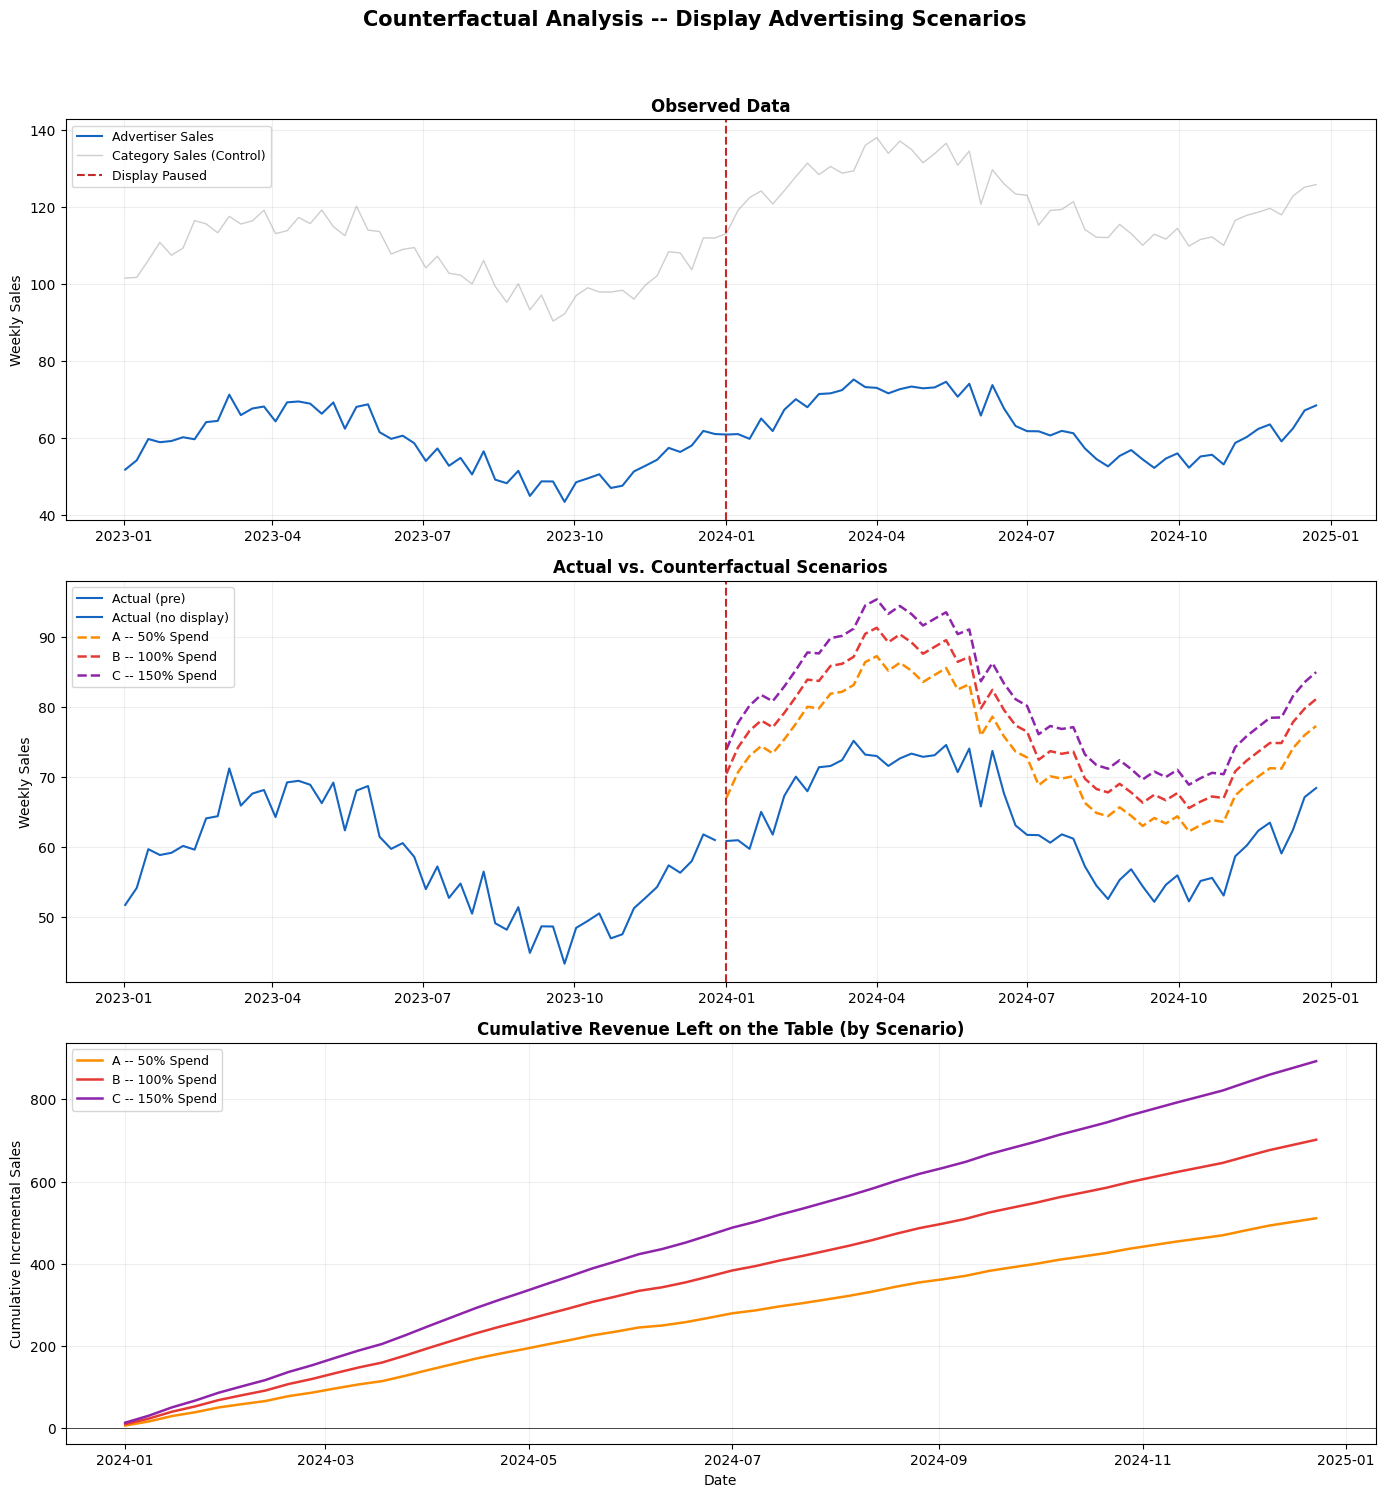

In [10]:
pre_dates = weeks[:intervention_week]
post_dates = weeks[intervention_week:]

scenario_colors = {
    "A -- 50% Spend":  "#FB8C00",
    "B -- 100% Spend": "#E53935",
    "C -- 150% Spend": "#8E24AA",
}

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle("Counterfactual Analysis -- Display Advertising Scenarios",
             fontsize=15, fontweight="bold", y=0.995)

# Panel 1: raw data
ax = axes[0]
ax.plot(weeks, advertiser_sales, color="#1565C0", lw=1.5, label="Advertiser Sales")
ax.plot(weeks, category_sales, color="#9E9E9E", lw=1, alpha=0.5,
        label="Category Sales (Control)")
ax.axvline(weeks[intervention_week], color="#C62828", ls="--", lw=1.5,
           label="Display Paused")
ax.set_ylabel("Weekly Sales")
ax.set_title("Observed Data", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 2: counterfactual scenarios vs actual
ax = axes[1]
ax.plot(pre_dates, y_pre, color="#1565C0", lw=1.5, label="Actual (pre)")
ax.plot(post_dates, y_post, color="#1565C0", lw=1.5, label="Actual (no display)")
for label, res in scenario_results.items():
    c = scenario_colors[label]
    ax.plot(post_dates, res["sales"], color=c, lw=1.8, ls="--", label=label)
ax.axvline(weeks[intervention_week], color="#C62828", ls="--", lw=1.5)
ax.set_ylabel("Weekly Sales")
ax.set_title("Actual vs. Counterfactual Scenarios", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

# Panel 3: cumulative incremental revenue
ax = axes[2]
for label, res in scenario_results.items():
    c = scenario_colors[label]
    ax.plot(post_dates, res["cumulative"], color=c, lw=1.8, label=label)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Cumulative Incremental Sales")
ax.set_title("Cumulative Revenue Left on the Table (by Scenario)", fontweight="bold")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Validation Plots

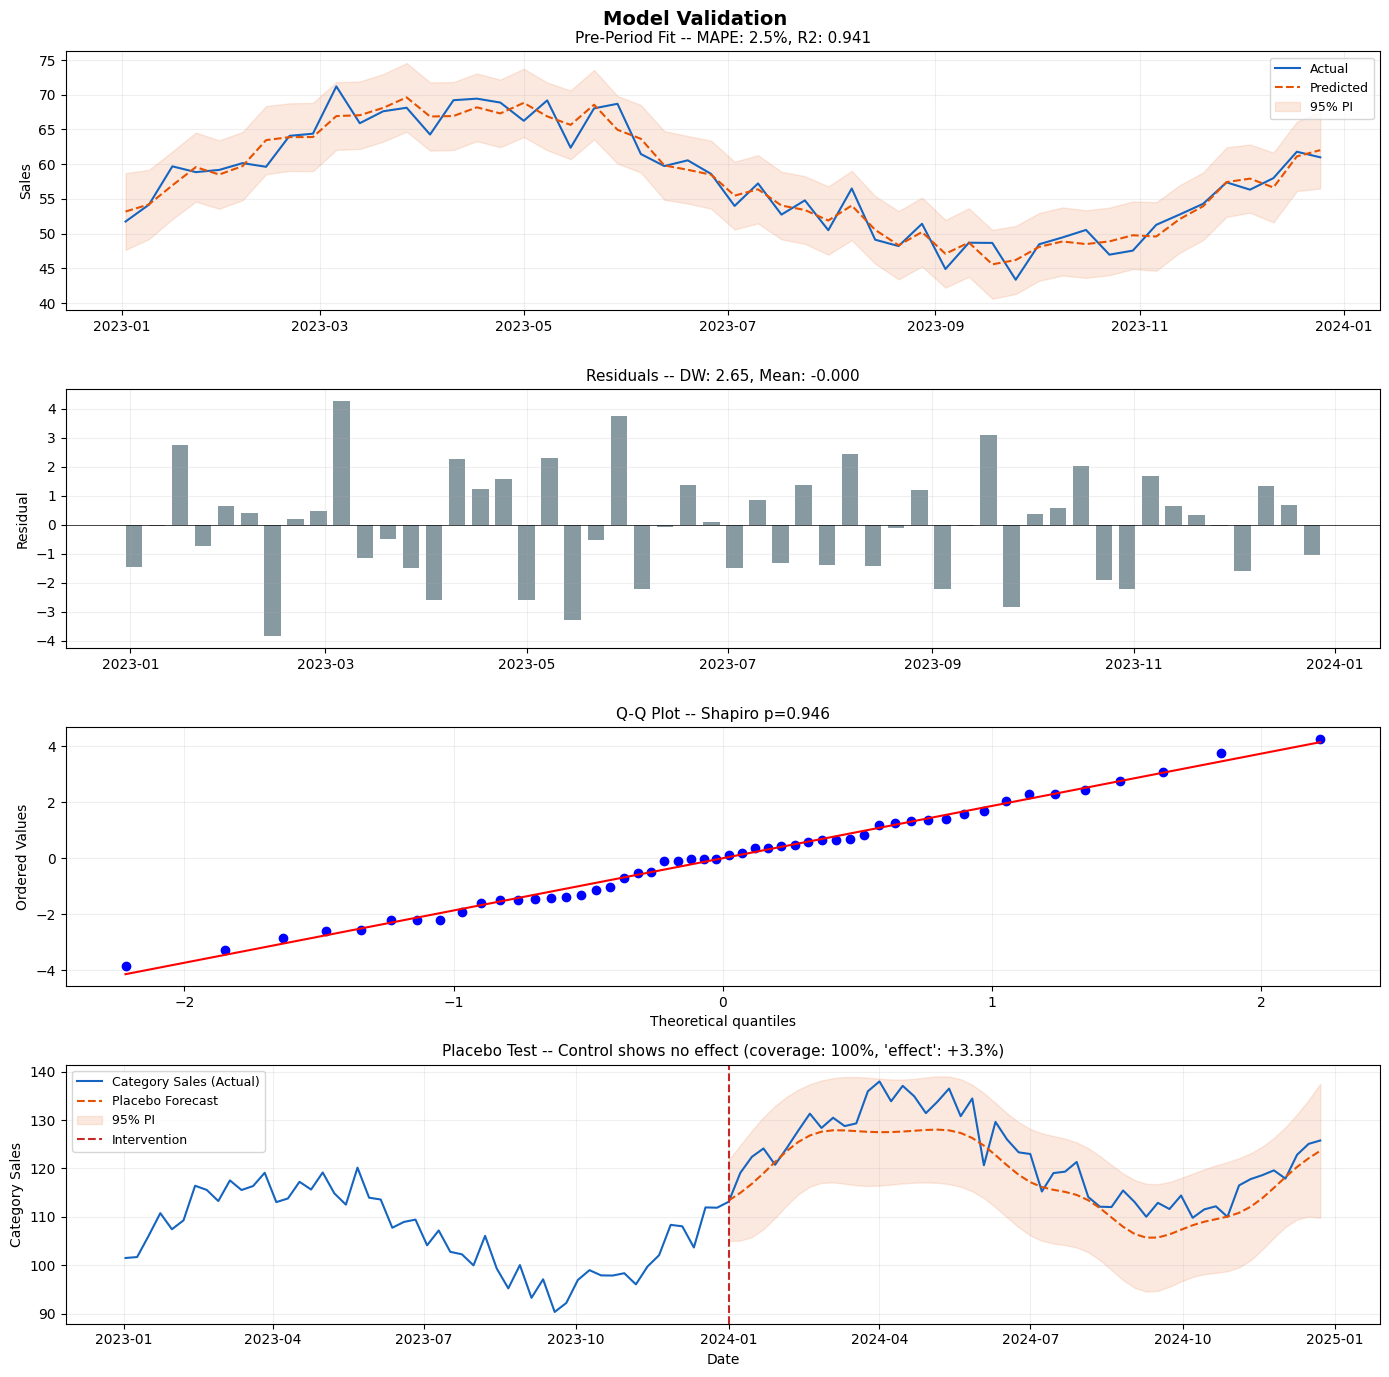

In [11]:
fig2, axes2 = plt.subplots(4, 1, figsize=(14, 14))
fig2.suptitle("Model Validation", fontsize=14, fontweight="bold")

ax = axes2[0]
ax.plot(pre_dates, y_pre, color="#1565C0", lw=1.5, label="Actual")
ax.plot(pre_dates, pre_pred, color="#E65100", lw=1.5, ls="--", label="Predicted")
ax.fill_between(pre_dates, pre_lower, pre_upper, alpha=0.12, color="#E65100",
                label="95% PI")
ax.set_title(f"Pre-Period Fit -- MAPE: {mape:.1f}%, R2: {model.rsquared:.3f}",
             fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2); ax.set_ylabel("Sales")

ax = axes2[1]
ax.bar(pre_dates, residuals, color="#546E7A", alpha=0.7, width=5)
ax.axhline(0, color="black", lw=0.5)
ax.set_title(f"Residuals -- DW: {dw:.2f}, Mean: {residuals.mean():.3f}", fontsize=11)
ax.grid(True, alpha=0.2); ax.set_ylabel("Residual")

ax = axes2[2]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title(f"Q-Q Plot -- Shapiro p={shapiro_p:.3f}", fontsize=11)
ax.grid(True, alpha=0.2)

ax = axes2[3]
ax.plot(weeks, category_sales, color="#1565C0", lw=1.5,
        label="Category Sales (Actual)")
ax.plot(post_dates, placebo_pred, color="#E65100", lw=1.5, ls="--",
        label="Placebo Forecast")
ax.fill_between(post_dates, placebo_lower, placebo_upper, alpha=0.12,
                color="#E65100", label="95% PI")
ax.axvline(weeks[intervention_week], color="#C62828", ls="--", lw=1.5,
           label="Intervention")
ax.set_title(f"Placebo Test -- Control shows no effect "
             f"(coverage: {placebo_coverage:.0f}%, "
             f"'effect': {placebo_pct:+.1f}%)", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
ax.set_ylabel("Category Sales"); ax.set_xlabel("Date")

plt.tight_layout()
plt.show()